## Config laden & Init

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import yaml

from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
from pathlib import Path
from typing import Any


# Load Constants
NB_PATH = Path(globals()["__vsc_ipynb_file__"]).resolve()
ROOT = NB_PATH.parent.parent 
FIG_PATH = ROOT / "reports" / "figures"
CONFIG_PATH = ROOT / "configs" / "config.yaml"
with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

CSV_PATH = ROOT / config["data"]["csv_path"]

# Initialisierung
rs = config["modeling"]["random_state"]
np.random.seed(rs)
dpi = config["modeling"]["dpi"]
df = pd.read_csv(CSV_PATH, sep=config["data"]["sep"])
figsize = config["modeling"]["figsize"]
blue_color = config["modeling"]["blue_color"]
grey_color = config["modeling"]["grey_color"]
default_color = config["modeling"]["default_color"]

# Init Plot
def save_plot(fig, title, save_path=FIG_PATH):
    filename = f"{title}.png"
    filepath = os.path.join(save_path, filename)
    fig.savefig(filepath, bbox_inches="tight", dpi=dpi)

def get_color_series(index, highlight_features, highlight_color=blue_color, default_color="lightgray"):
    return [highlight_color if feature in highlight_features else default_color for feature in index]

# CSV laden
df.columns = df.columns.str.strip()
df["KW"] = df.index
df["Datum"] = pd.to_datetime(config["data"]["start_date"]) + pd.to_timedelta(df["KW"] * 7, unit="D")
df["Monat_Jahr"] = df["Datum"].dt.to_period("M").dt.to_timestamp()

# Featureset
features = config["featuresset"]["features"]
target = config["featuresset"]["target"]

# Zielvariable
df[target] = df["Alle Abschlüsse"]

# Monatsaggregation
df_monthly = df.groupby(config["aggregation"]["groupby_col"]).agg(config["aggregation"]["agg_map"])

X = df_monthly[features].dropna()
y = df_monthly[target].loc[X.index]


## Baseline - Lineare Regression mit 80/20 Split

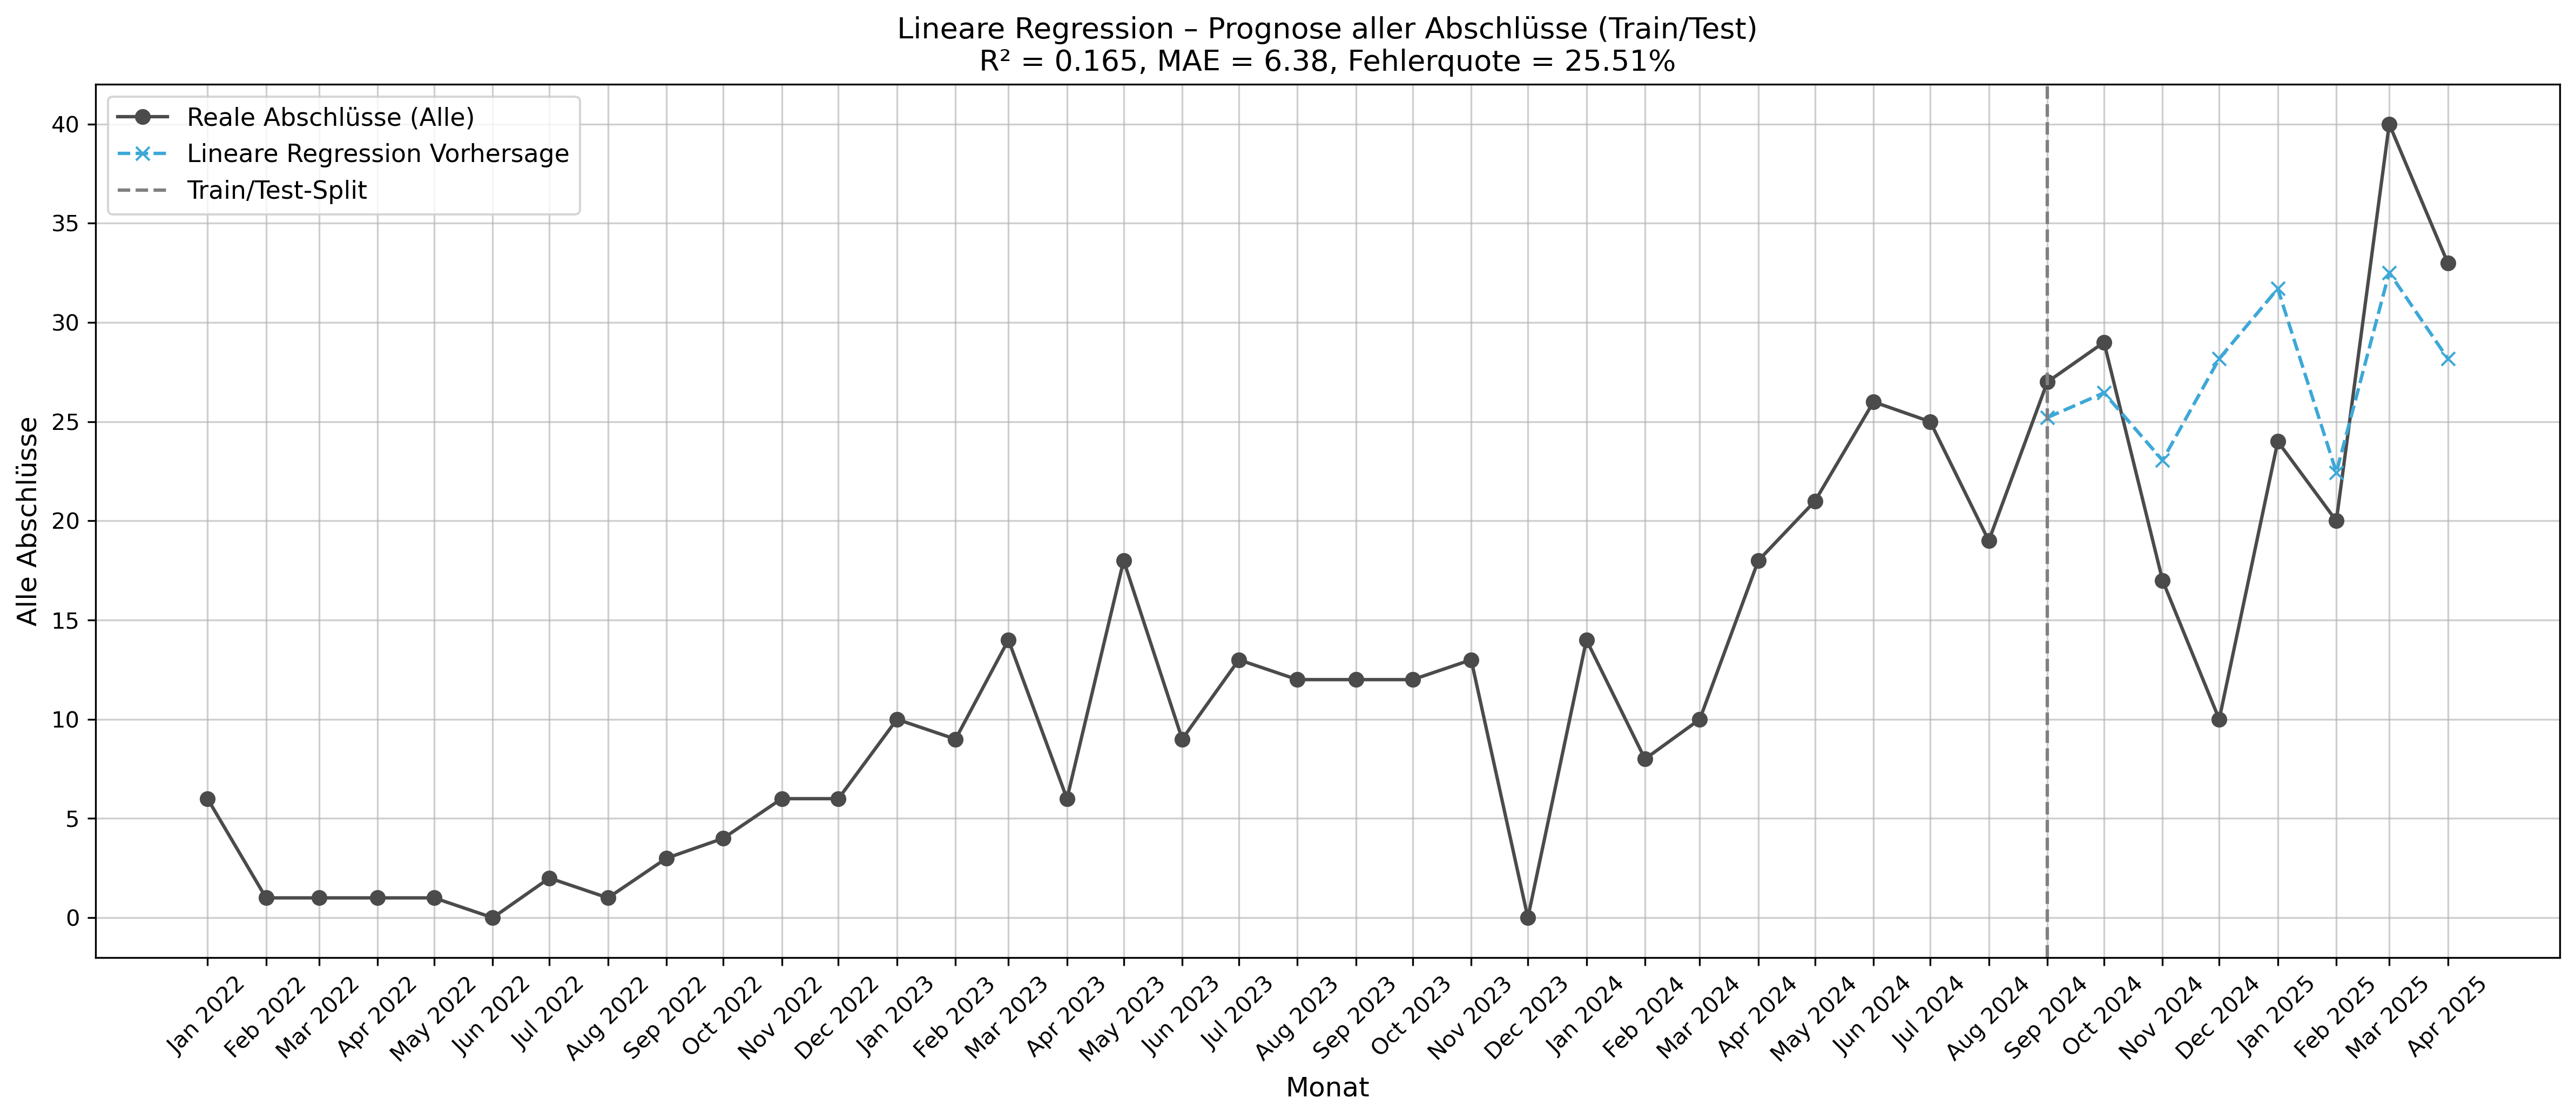

In [26]:
# Train/Test-Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Modell
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metriken
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
fehlerquote = mae / np.mean(y_test) * 100

# Plot
title = "Lineare Regression – Prognose aller Abschlüsse"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(y_test.index, y_pred, label="Lineare Regression Vorhersage", linestyle='--', marker='x', color=blue_color)
ax.axvline(x=y.index[split_idx], color="gray", linestyle="--", label="Train/Test-Split")

ax.set_title(f"{title} (Train/Test)\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13) 
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()


## Baseline - SARIMAX mit 80/20 Split

/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/envs/ml-mac/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


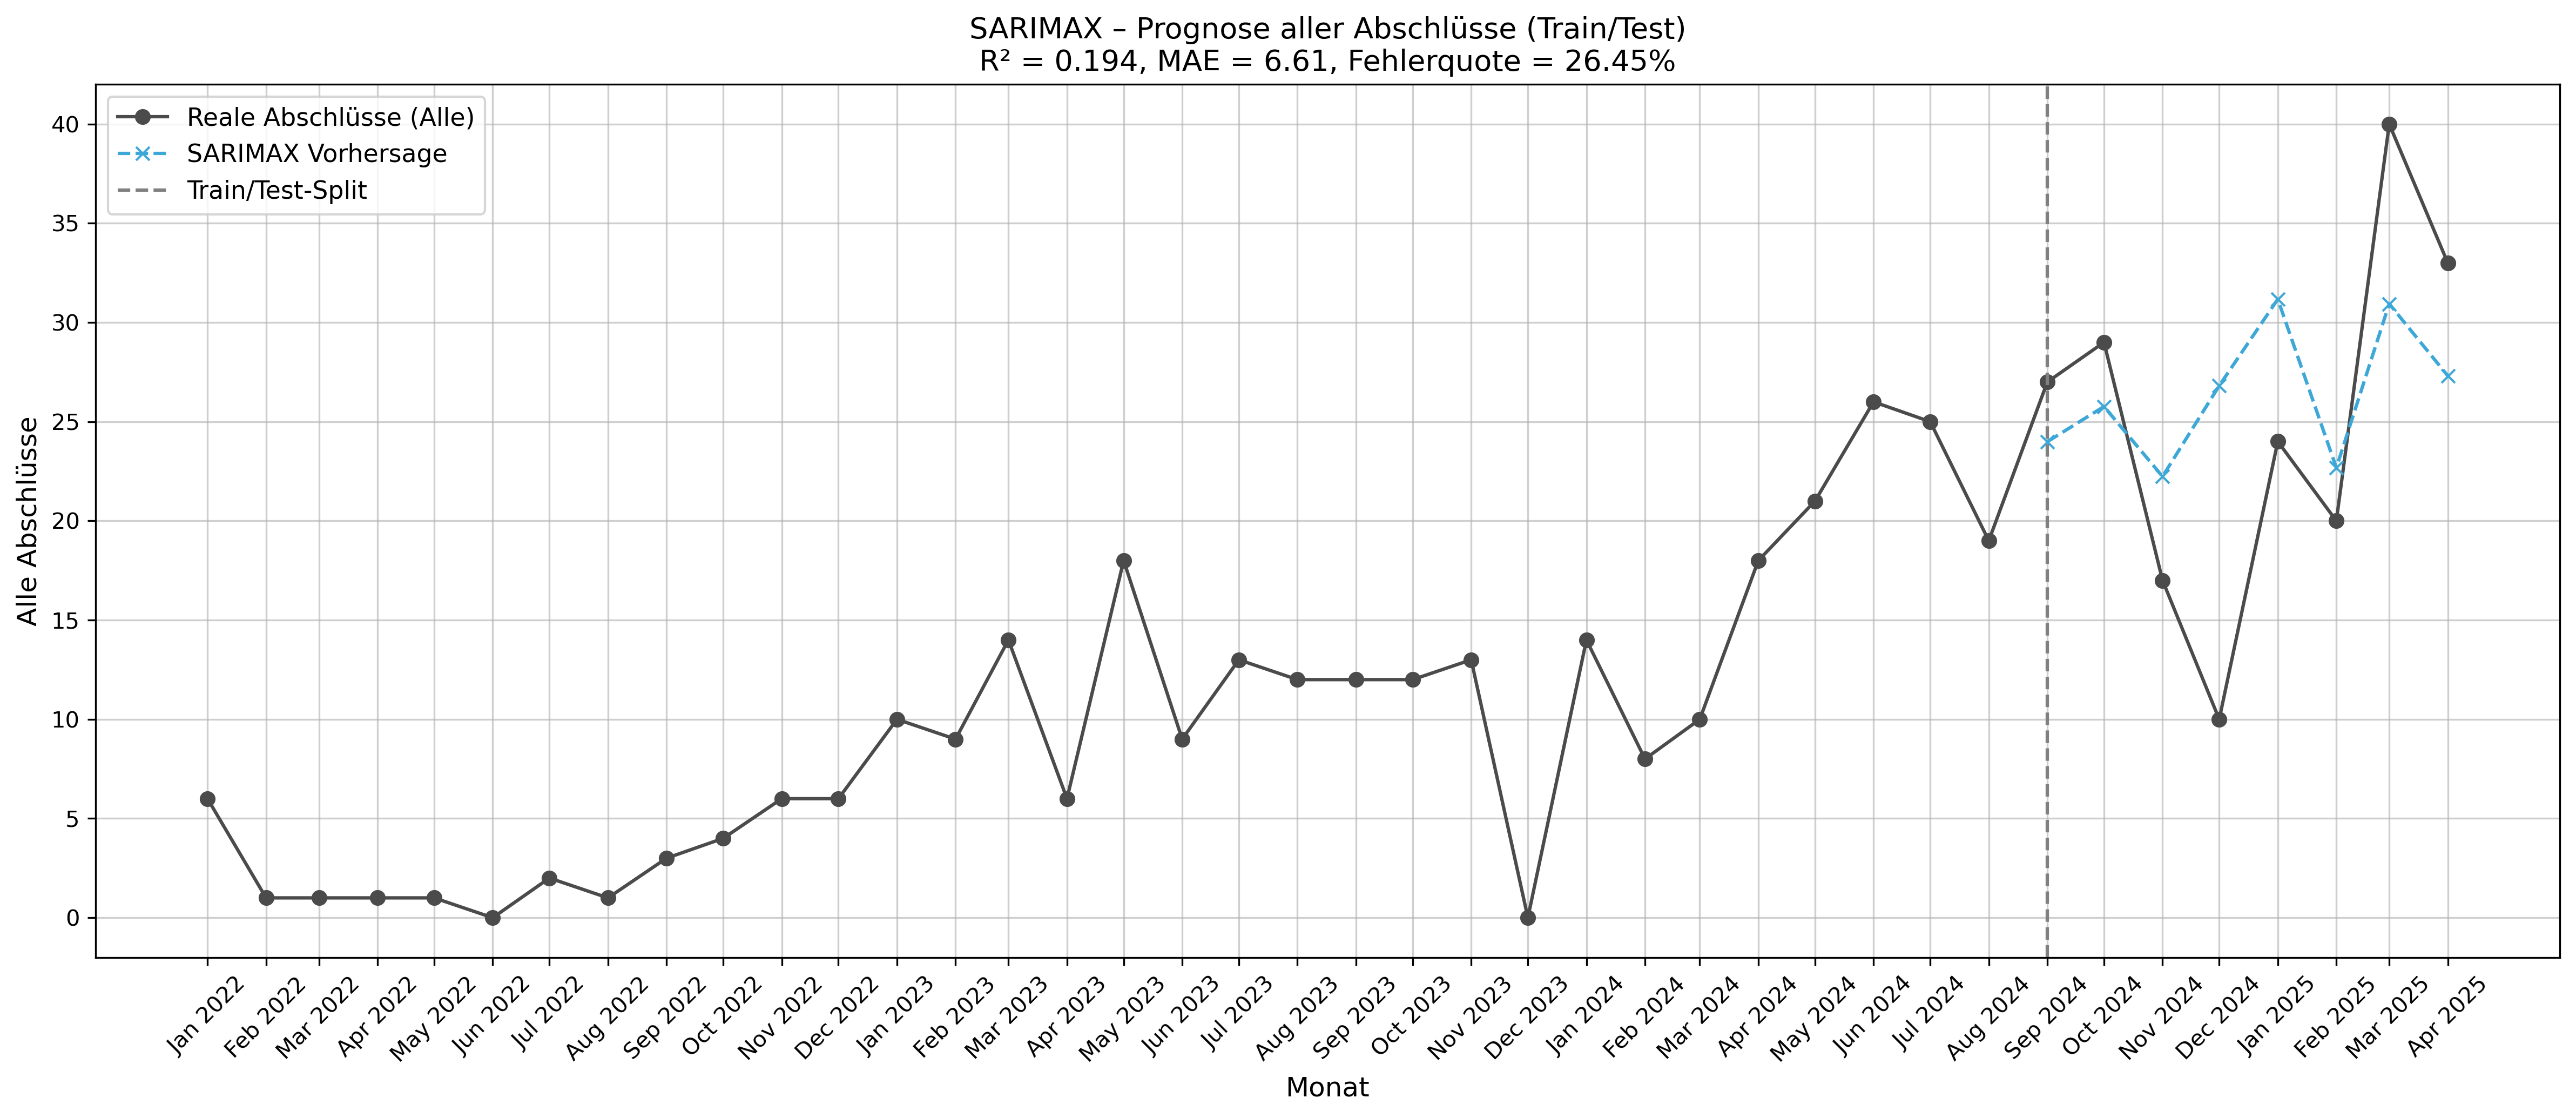

In [27]:
# 80/20 Split
split_idx = int(len(X) * 0.8)
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]

# SARIMAX Modell (ohne Saisonalität, einfache Differenzierung)
model = SARIMAX(endog=y_train, exog=X_train, order=(0, 1, 0), enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# Prognose
sarimax_res: Any = model.fit(disp=False)
y_pred = sarimax_res.predict(start=X_test.index[0], end=X_test.index[-1], exog=X_test)
# Metriken
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
fehlerquote = mae / np.mean(y_test) * 100

# Plot
title = "SARIMAX – Prognose aller Abschlüsse"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(y_test.index, y_pred, label="SARIMAX Vorhersage", linestyle='--', marker='x', color="#3DA8D7")
ax.axvline(x=y.index[split_idx], color="gray", linestyle="--", label="Train/Test-Split")

ax.set_title(f"{title} (Train/Test)\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13) 
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()


## Baseline - XGBoost mit 80/20 Split

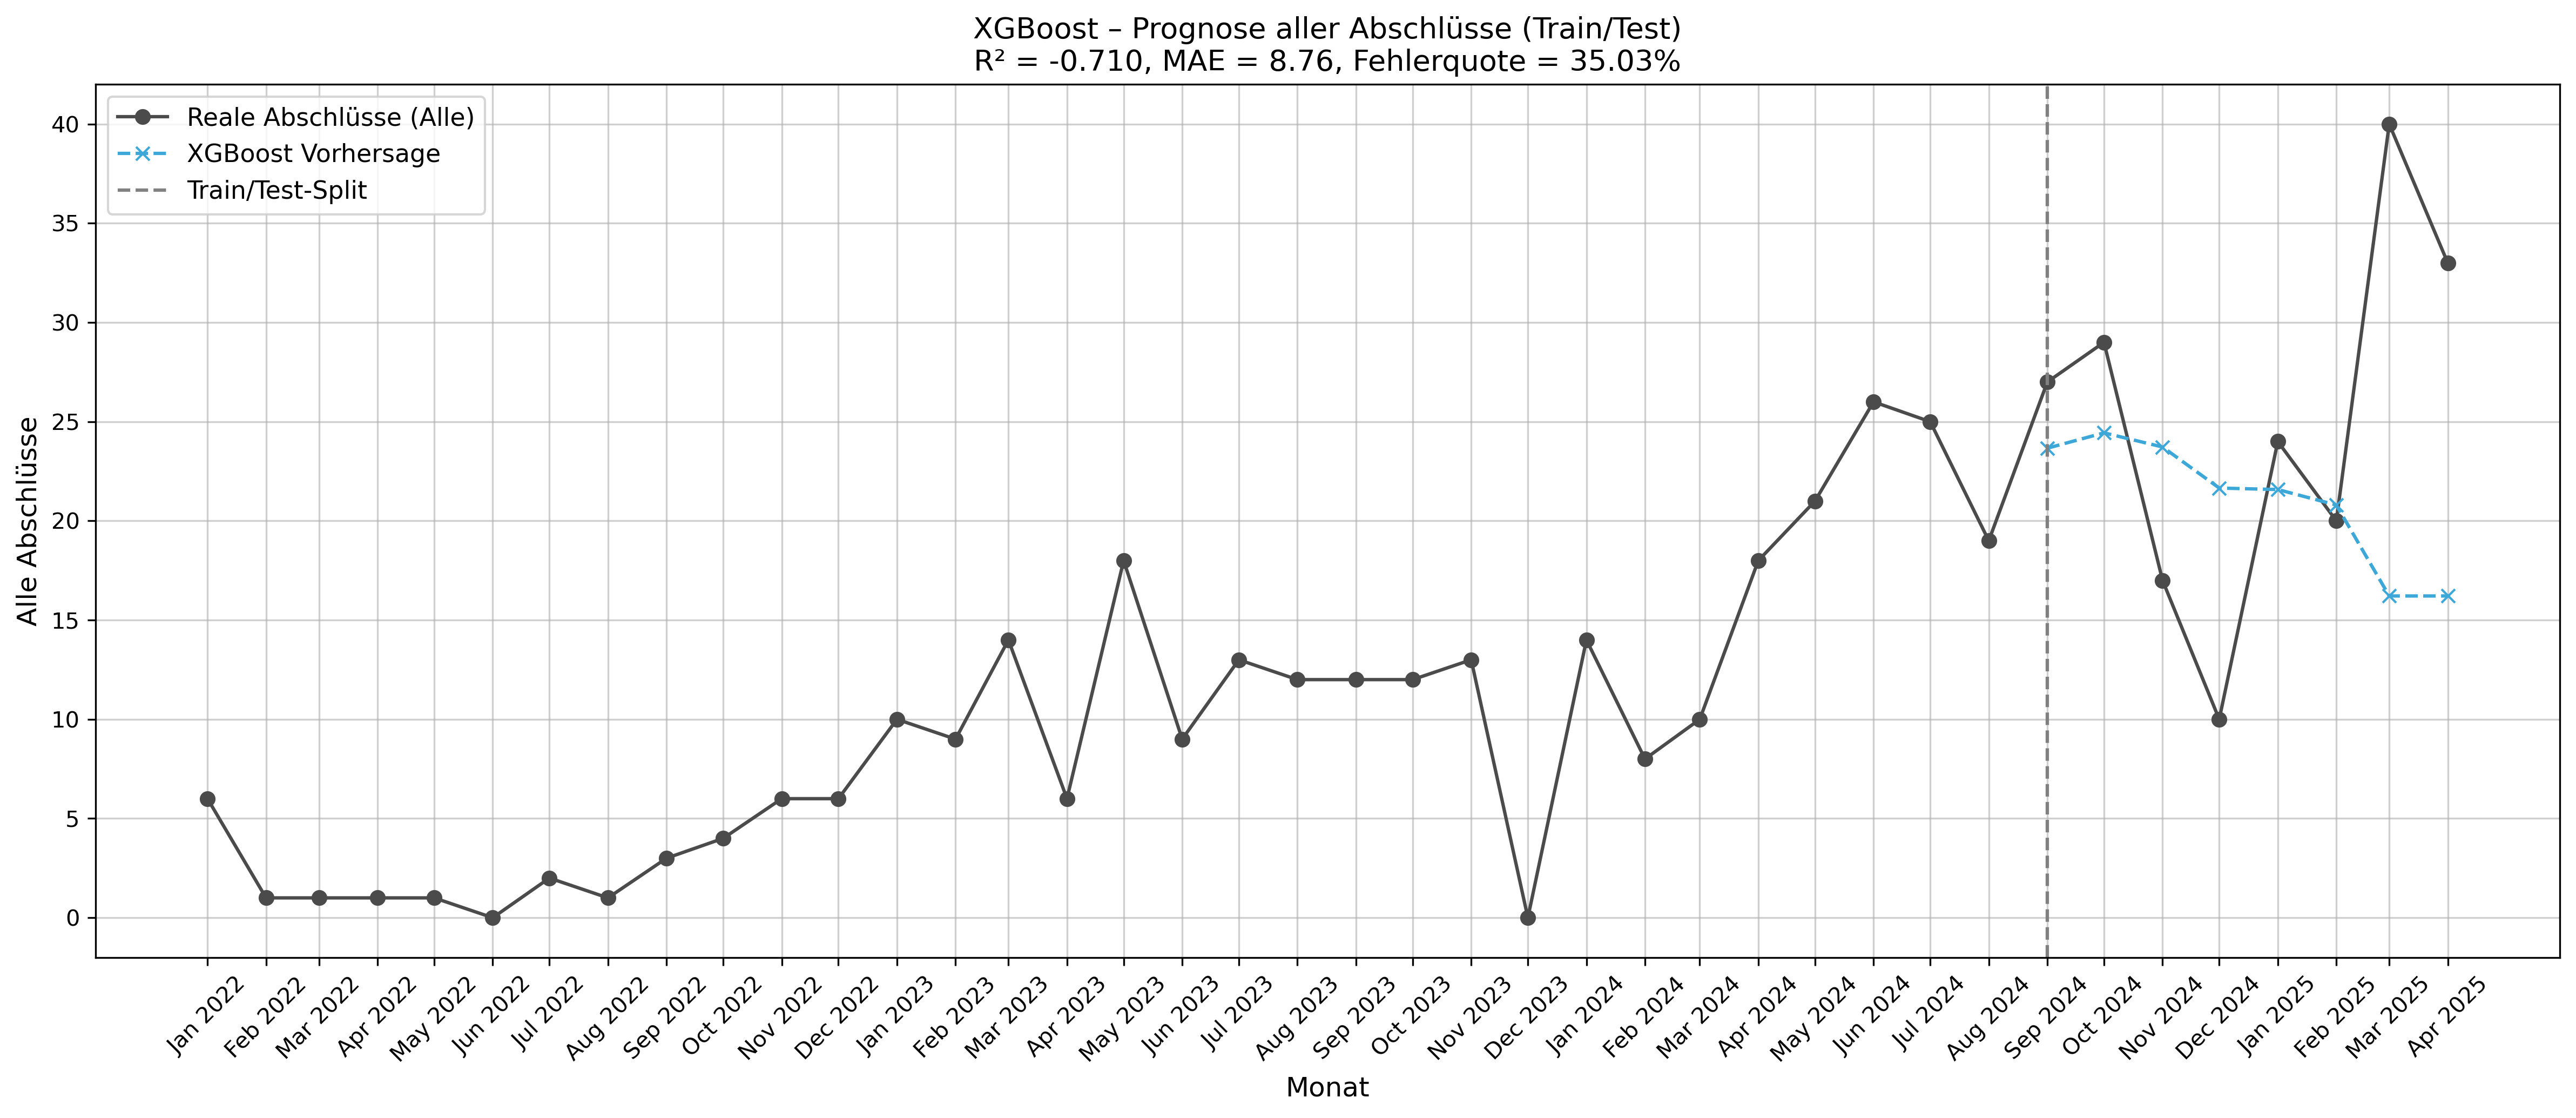

In [28]:
# Train/Test-Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Modell trainieren
model = XGBRegressor(n_estimators=dpi, max_depth=3, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metriken
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
fehlerquote = mae / np.mean(y_test) * 100

# Plot
title = "XGBoost – Prognose aller Abschlüsse"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(y_test.index, y_pred, label="XGBoost Vorhersage", linestyle='--', marker='x', color="#3DA8D7")
ax.axvline(x=y.index[split_idx], color="gray", linestyle="--", label="Train/Test-Split")

ax.set_title(f"{title} (Train/Test)\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()

## Lasso Regression mit 80/20 Split

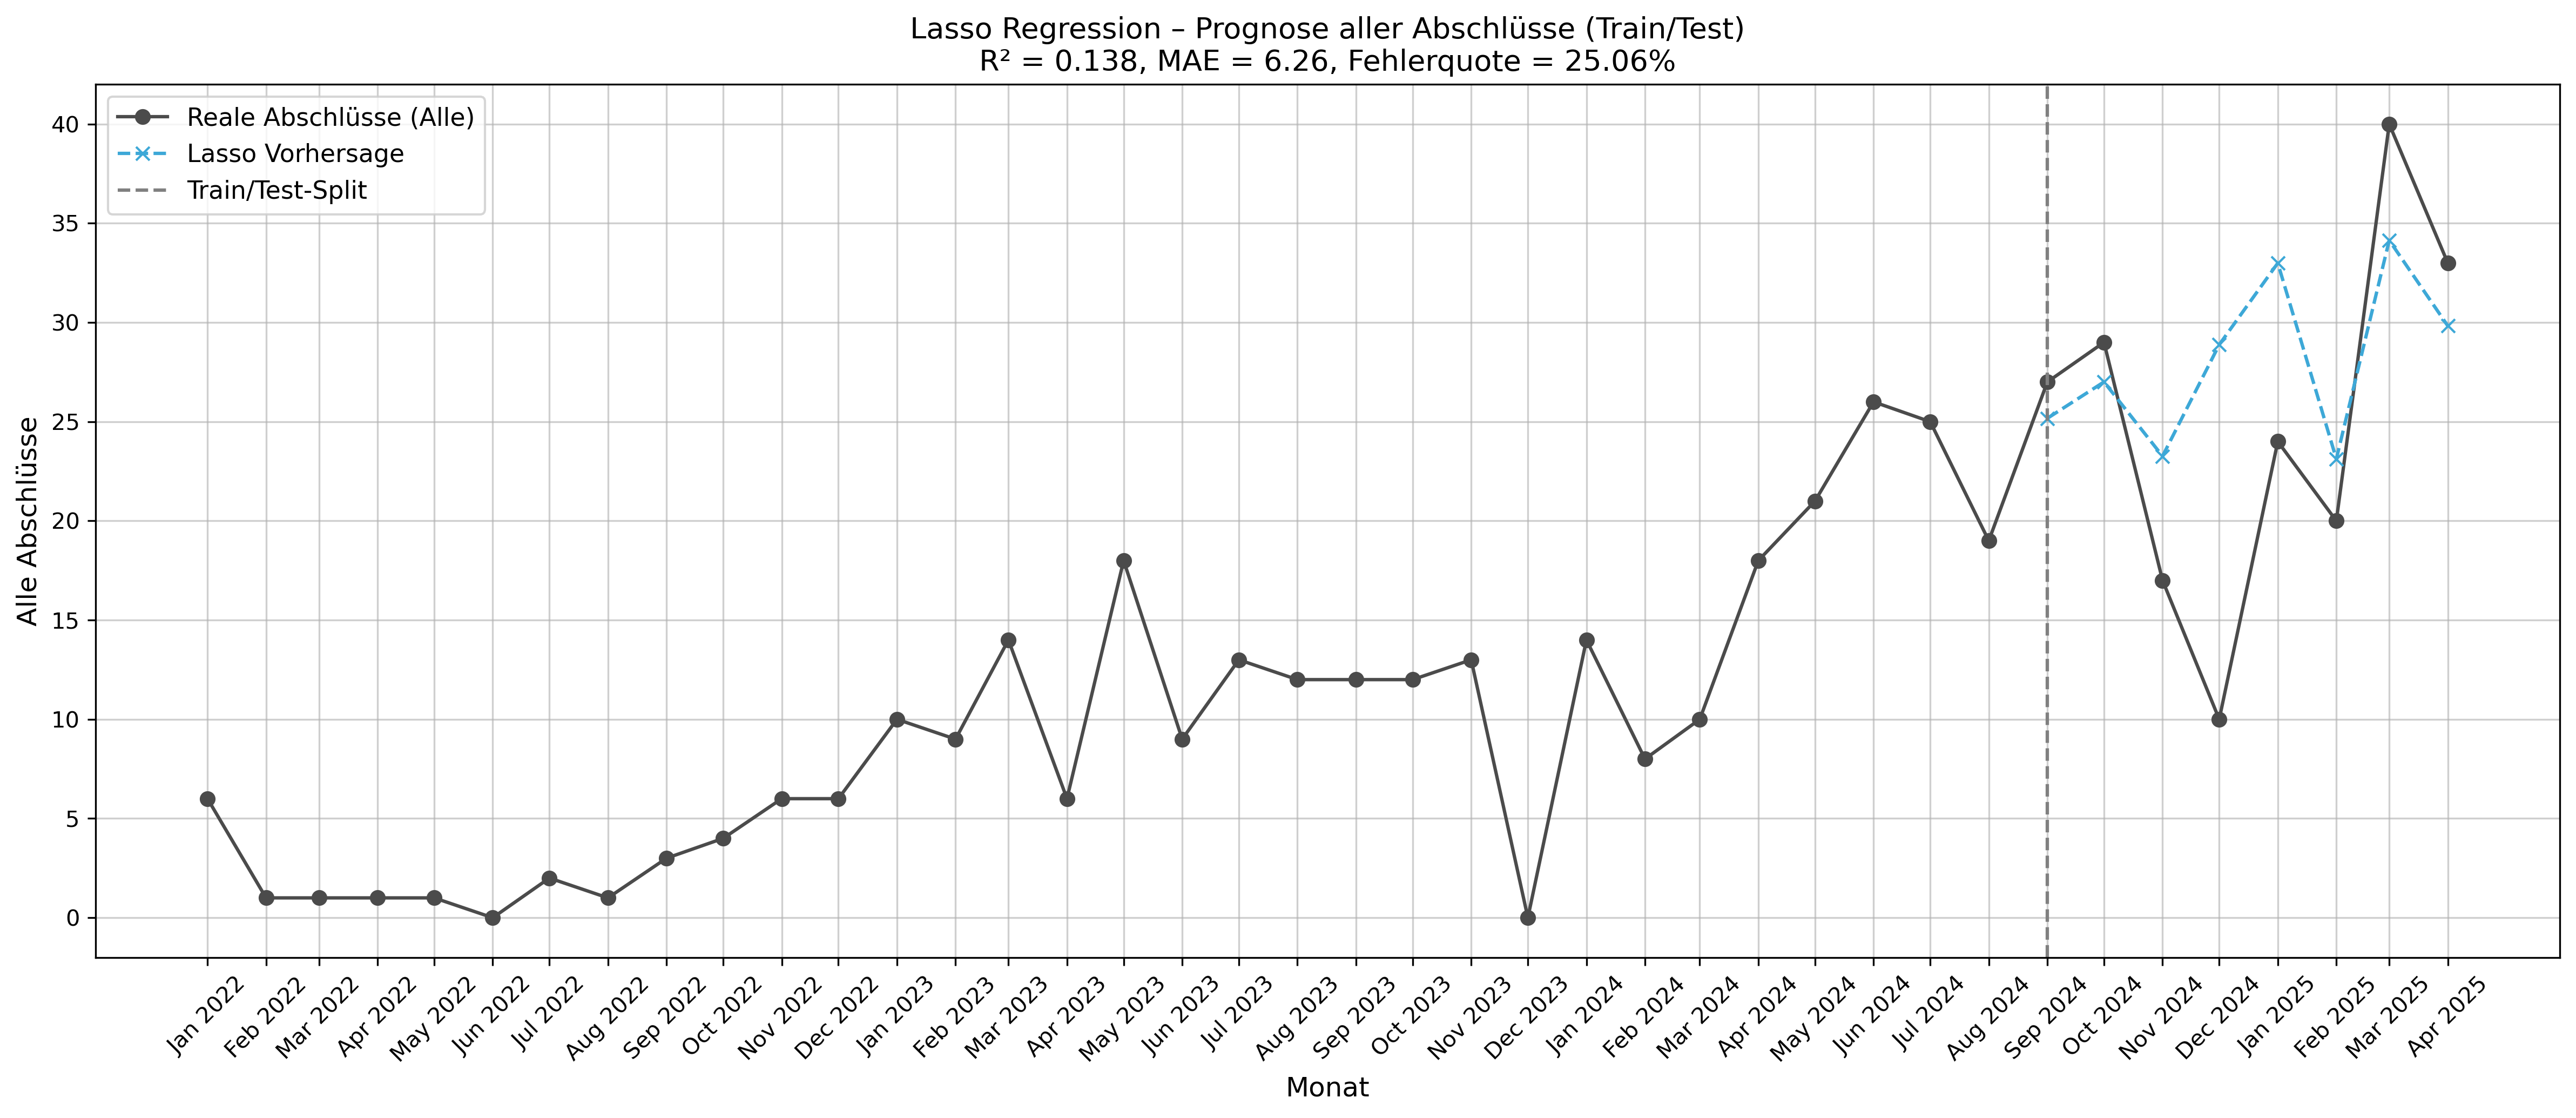

In [29]:
# Zeitbasierter Train/Test-Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Lasso-Modell mit Cross-Validation
model = LassoCV(cv=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metriken
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
fehlerquote = mae / np.mean(y_test) * 100


# Plot
title = "Lasso Regression – Prognose aller Abschlüsse"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(y_test.index, y_pred, label="Lasso Vorhersage", linestyle='--', marker='x', color="#3DA8D7")
ax.axvline(x=y.index[split_idx], color="gray", linestyle="--", label="Train/Test-Split")

ax.set_title(f"{title} (Train/Test)\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()


## Baseline - Ridge Regression mit 80/20 Split

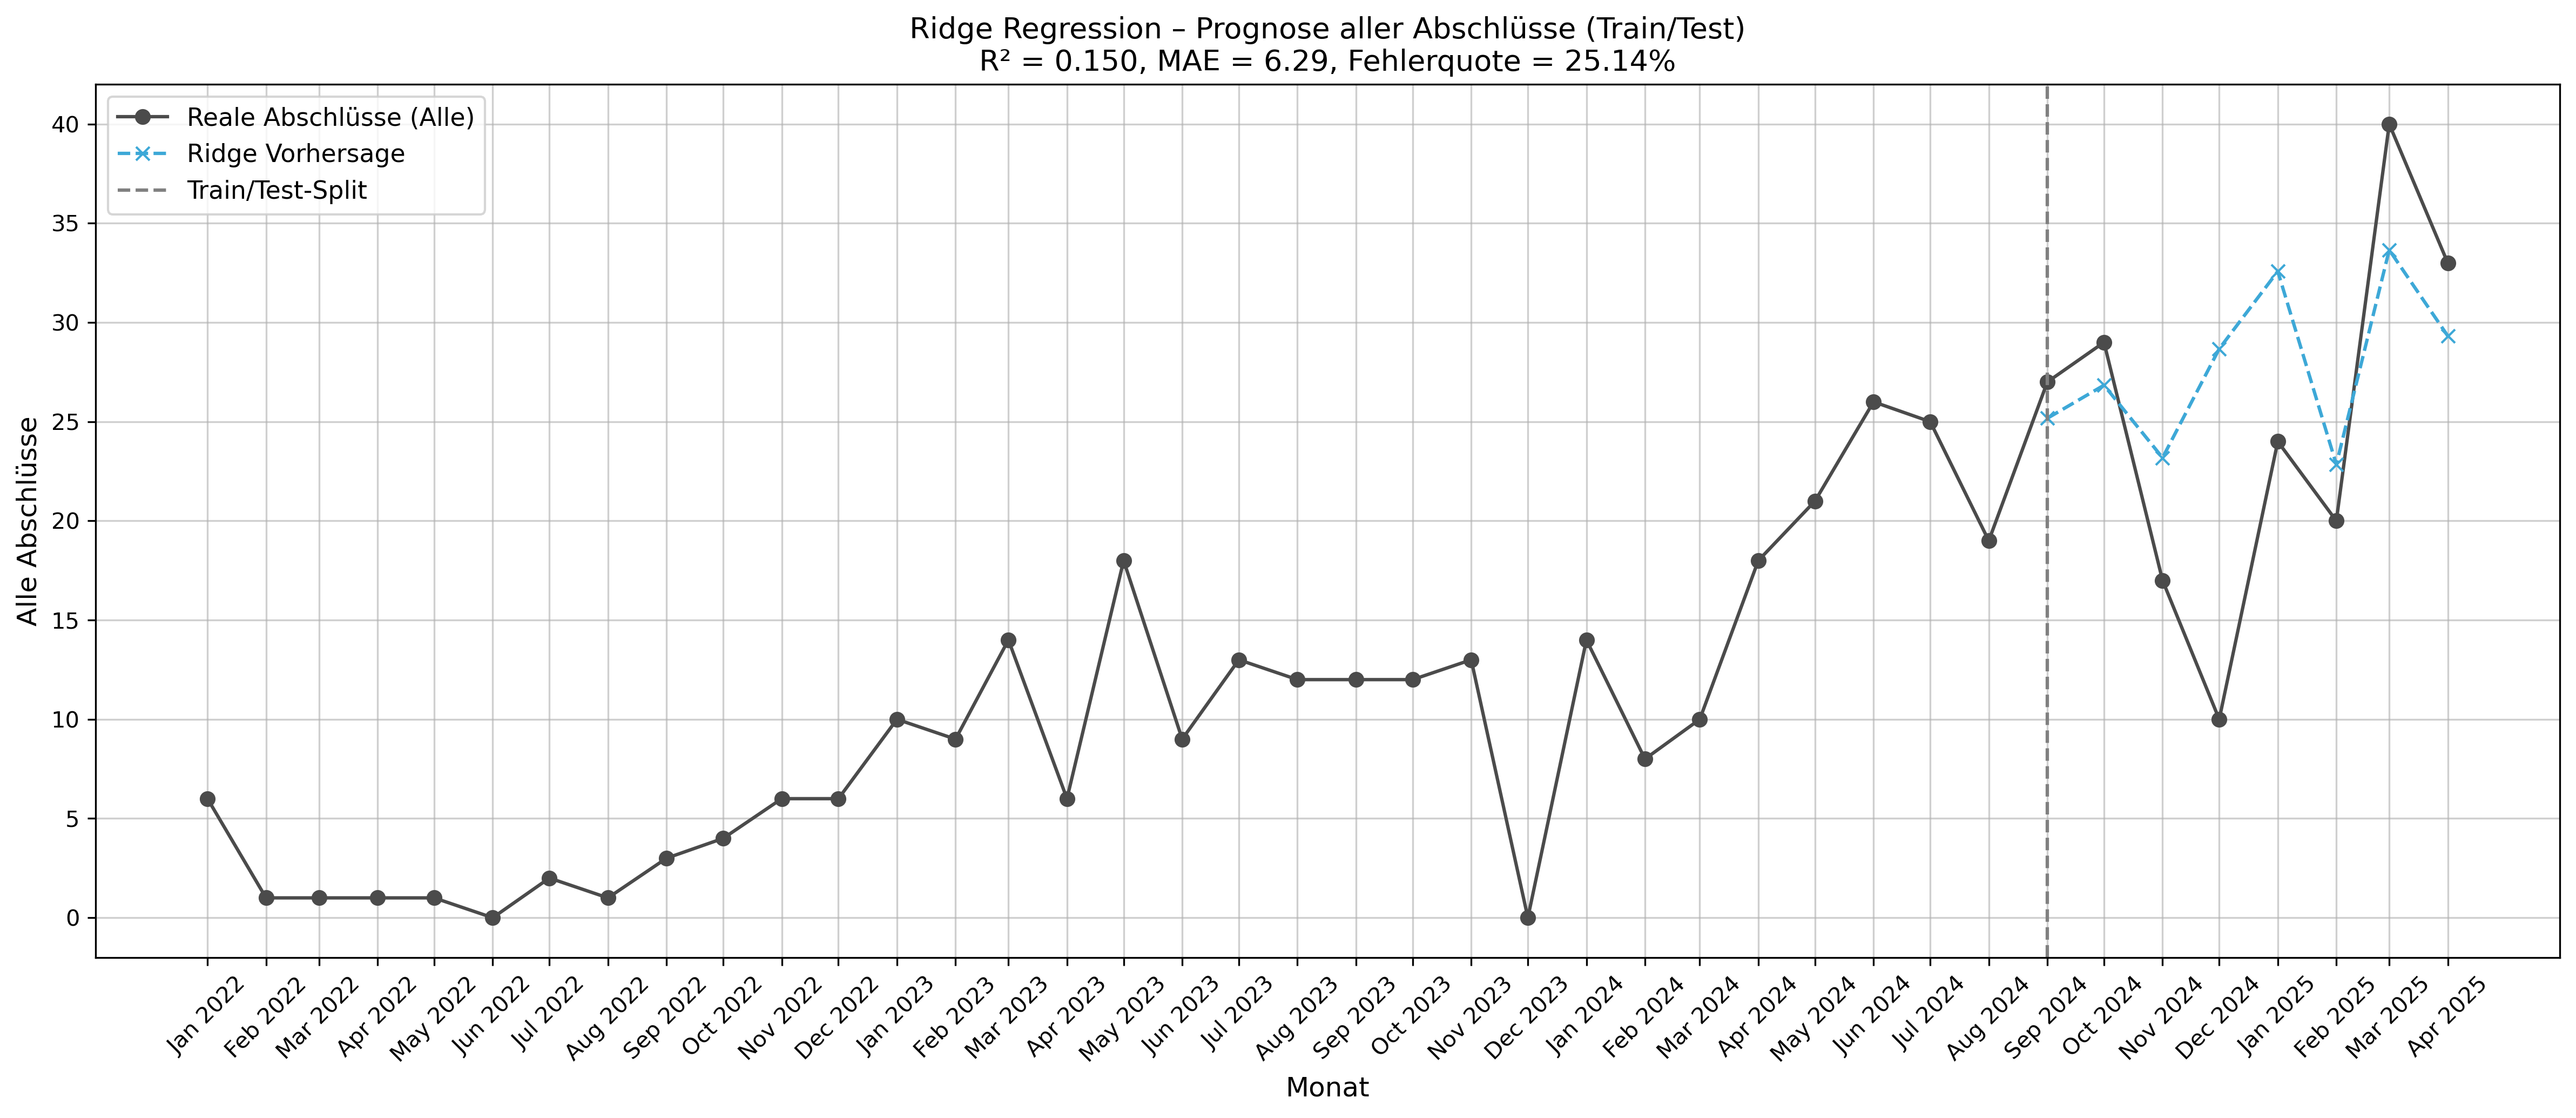

In [30]:
# Zeitbasierter Train/Test-Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Ridge-Modell mit Cross-Validation
alphas = np.logspace(-3, 3, 100)
model = RidgeCV(alphas=alphas, cv=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Metriken
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
fehlerquote = mae / np.mean(y_test) * 100

# Plot
title = "Ridge Regression – Prognose aller Abschlüsse"
fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

ax.plot(y.index, y, label="Reale Abschlüsse (Alle)", marker='o', color=grey_color)
ax.plot(y_test.index, y_pred, label="Ridge Vorhersage", linestyle='--', marker='x', color="#3DA8D7")
ax.axvline(x=y.index[split_idx], color="gray", linestyle="--", label="Train/Test-Split")

ax.set_title(f"{title} (Train/Test)\nR² = {r2:.3f}, MAE = {mae:.2f}, Fehlerquote = {fehlerquote:.2f}%", fontsize=13)
ax.set_xlabel("Monat", fontsize=12)
ax.set_ylabel("Alle Abschlüsse", fontsize=12)
ax.set_xticks(y.index)
ax.set_xticklabels([d.strftime('%b %Y') for d in y.index], rotation=45, fontsize=10)
ax.legend(fontsize=11)
ax.grid(True, linestyle='-', alpha=0.6)

plt.tight_layout()
save_plot(fig, title)
plt.show()
